# 🇰🇪 Kenya Development Story: An Exploratory Data Analysis
**Data source:** World Bank — World Development Indicators (WDI)  
**Coverage:** 1960–2025 | 1,486 indicators  
**Themes:** Economy & GDP · Health & Demographics · Education · Trade · Digital Infrastructure

---
### Project overview
This notebook explores Kenya's development trajectory over six decades using the World Bank's WDI dataset. Each section investigates a key dimension of national development, combining statistical summaries with visualisations to surface trends, anomalies, and correlations.

**Sections:**
1. Setup & data loading
2. Dataset overview & quality audit
3. Economy & GDP
4. Health & demographics
5. Education
6. Trade & exports
7. Digital & infrastructure
8. Cross-theme correlation analysis
9. Key findings & conclusions

## 1. Setup & data loading

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
PALETTE = ['#1D9E75', '#378ADD', '#D85A30', '#7F77DD', '#BA7517', '#D4537E']
sns.set_palette(PALETTE)
print('Libraries loaded ✓')

Libraries loaded ✓


In [41]:
# ── Load dataset ────────────────────────────────────────────────────────────
# Upload the file first (Files panel → upload), then run this cell.

FILE = 'API_KEN_DS2_en_csv_v2_5938.csv'   # adjust path if needed

raw = pd.read_csv(FILE, skiprows=4)

# Clean up: drop the empty trailing column World Bank files sometimes include
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')]

# Separate metadata from year columns
META_COLS = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
YEAR_COLS = [c for c in raw.columns if c.isdigit()]

print(f'Shape: {raw.shape}')
print(f'Year range: {YEAR_COLS[0]} – {YEAR_COLS[-1]}  ({len(YEAR_COLS)} years)')
print(f'Total indicators: {raw["Indicator Name"].nunique()}')
raw.index = range(1, len(raw) + 1)
raw.head(5)

Shape: (1486, 70)
Year range: 1960 – 2025  (66 years)
Total indicators: 1486


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
1,Kenya,KEN,"Internally displaced persons, new displacement...",VC.IDP.NWDS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.900000e+04,35000.000000,336000.000000,74000.000000,335000.000000,36000.000000,318000.000000,641000.000000,NaN,NaN
2,Kenya,KEN,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,4.603231e+01,42.878083,42.345836,47.114626,32.441265,33.364268,34.839385,29.308730,29.272267,NaN
3,Kenya,KEN,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,1.868434e+01,17.247652,16.323495,17.223310,22.346221,24.188235,18.004547,13.293216,12.980601,NaN
4,Kenya,KEN,"Merchandise exports by the reporting economy, ...",TX.VAL.MRCH.RS.ZS,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,...,4.231871e-07,0.000000,0.503800,0.000084,0.001691,0.008876,0.006300,0.007285,NaN,NaN
5,Kenya,KEN,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R3.ZS,0.40568,0.393314,0.273473,0.246508,0.232558,NaN,...,4.615607e-01,0.458185,0.251096,0.140933,0.123891,0.123046,0.276358,0.194086,NaN,NaN


## 2. Dataset overview & quality audit

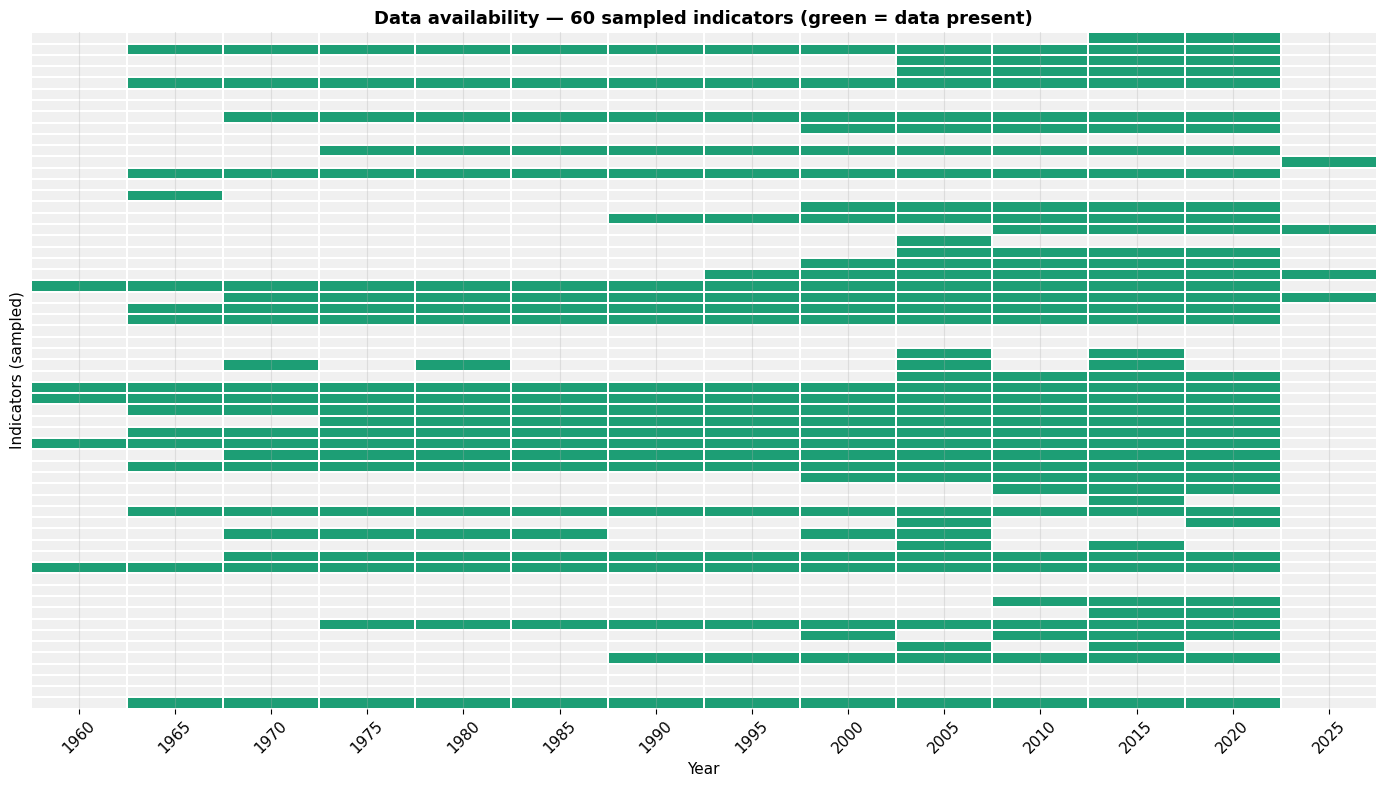

Indicators with any data 2000–2024: 1364 / 1486 (92%)


In [42]:
# ── Helper: fetch a single indicator series ────────────────────────────────
def get_series(indicator_name, years=None):
    """Return a pd.Series indexed by year for the given indicator."""
    row = raw[raw['Indicator Name'] == indicator_name]
    if row.empty:
        raise ValueError(f'Indicator not found: {indicator_name}')
    s = row[YEAR_COLS].iloc[0].astype(float)
    s.index = s.index.astype(int)
    if years:
        s = s[s.index.isin(years)]
    return s.dropna()


# ── Missing data heatmap ───────────────────────────────────────────────────
# Sample 60 indicators for readability
sample = raw.sample(60, random_state=42).set_index('Indicator Name')[YEAR_COLS].astype(float)
decade_cols = [c for c in YEAR_COLS if int(c) % 5 == 0]  # every 5 years

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    sample[decade_cols].notna().astype(int),
    cmap=['#f0f0f0', '#1D9E75'], cbar=False,
    linewidths=0.3, ax=ax, yticklabels=False
)
ax.set_title('Data availability — 60 sampled indicators (green = data present)')
ax.set_xlabel('Year')
ax.set_ylabel('Indicators (sampled)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Coverage stats
recent_yrs = [str(y) for y in range(2000, 2025)]
coverage = (raw[recent_yrs].notna().sum(axis=1) > 0).sum()
print(f'Indicators with any data 2000–2024: {coverage} / {len(raw)} ({coverage/len(raw)*100:.0f}%)')

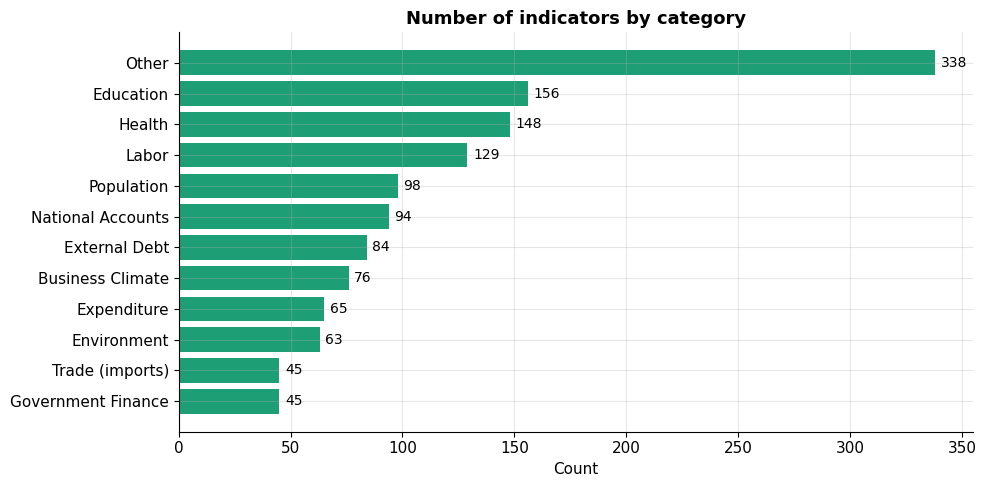

In [43]:
# ── Indicator category breakdown ───────────────────────────────────────────
raw['Category'] = raw['Indicator Code'].str.split('.').str[0]
cat_map = {
    'SE': 'Education', 'SH': 'Health', 'SL': 'Labor', 'SP': 'Population',
    'NY': 'National Accounts', 'DT': 'External Debt', 'IC': 'Business Climate',
    'NE': 'Expenditure', 'EN': 'Environment', 'TM': 'Trade (imports)',
    'GC': 'Government Finance', 'TX': 'Trade (exports)', 'EG': 'Energy',
    'AG': 'Agriculture', 'NV': 'Value Added', 'SI': 'Poverty & Inequality'
}
raw['Category Label'] = raw['Category'].map(cat_map).fillna('Other')

top_cats = raw['Category Label'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1], color=PALETTE[0])
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title('Number of indicators by category')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## 3. Economy & GDP

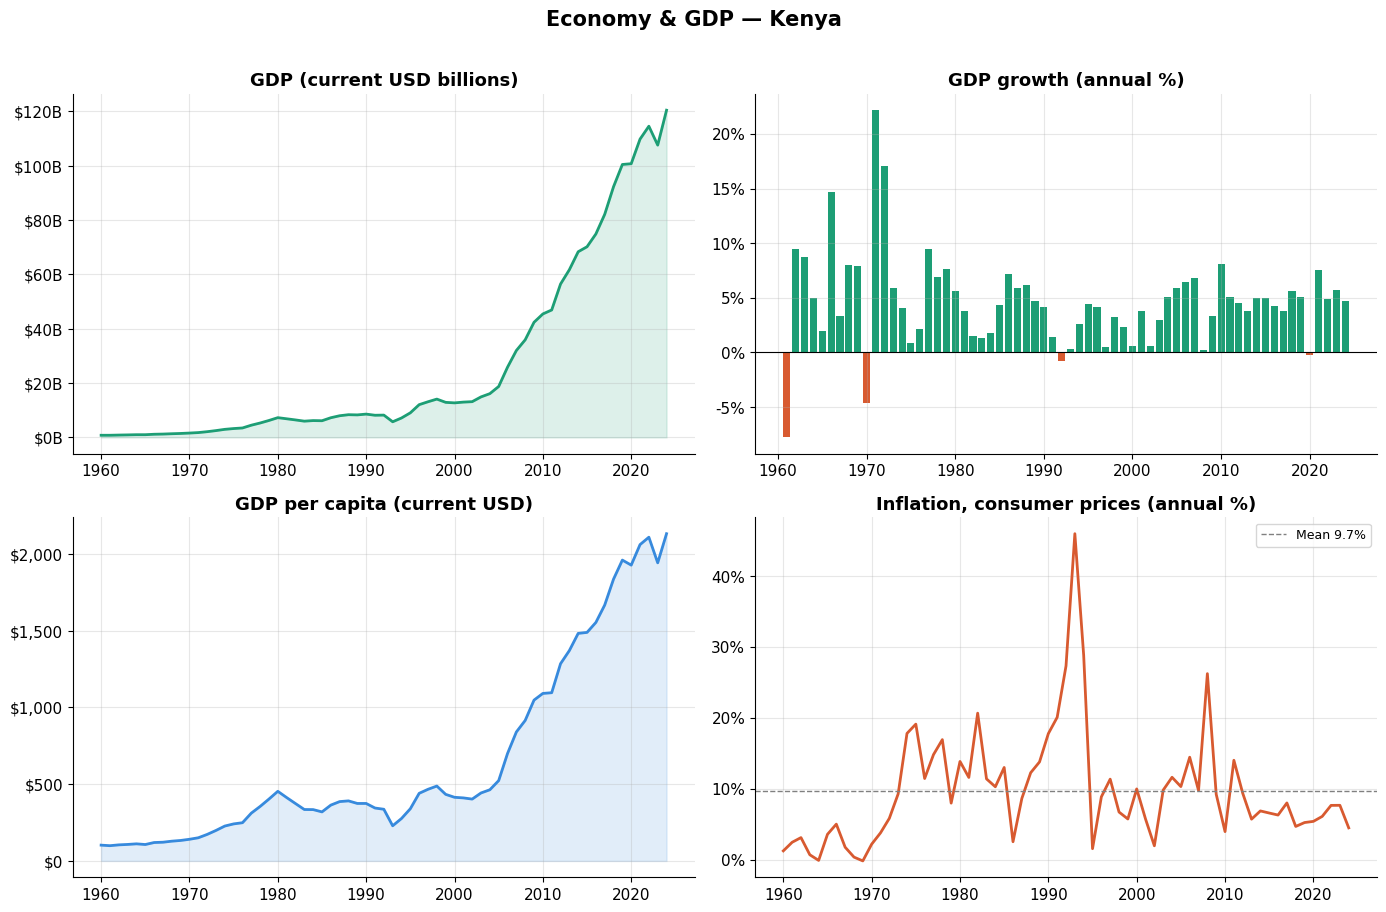


── GDP summary statistics ──


,count,mean,std,min,25%,50%,75%,max
GDP (US$B),65.0,25.99,34.67,0.79,3.47,8.28,35.9,120.34


In [44]:
gdp        = get_series('GDP (current US$)') / 1e9
gdp_growth = get_series('GDP growth (annual %)')
gdp_pc     = get_series('GDP per capita (current US$)')
inflation  = get_series('Inflation, consumer prices (annual %)')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Economy & GDP — Kenya', fontsize=15, fontweight='bold', y=1.01)

# GDP absolute
ax = axes[0, 0]
ax.fill_between(gdp.index, gdp.values, alpha=0.15, color=PALETTE[0])
ax.plot(gdp.index, gdp.values, color=PALETTE[0], linewidth=2)
ax.set_title('GDP (current USD billions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# GDP growth
ax = axes[0, 1]
colors = [PALETTE[0] if v >= 0 else PALETTE[2] for v in gdp_growth.values]
ax.bar(gdp_growth.index, gdp_growth.values, color=colors, width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('GDP growth (annual %)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# GDP per capita
ax = axes[1, 0]
ax.fill_between(gdp_pc.index, gdp_pc.values, alpha=0.15, color=PALETTE[1])
ax.plot(gdp_pc.index, gdp_pc.values, color=PALETTE[1], linewidth=2)
ax.set_title('GDP per capita (current USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Inflation
ax = axes[1, 1]
ax.plot(inflation.index, inflation.values, color=PALETTE[2], linewidth=2)
ax.axhline(inflation.mean(), color='gray', linestyle='--', linewidth=1, label=f'Mean {inflation.mean():.1f}%')
ax.set_title('Inflation, consumer prices (annual %)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

print('\n── GDP summary statistics ──')
display(gdp.describe().rename('GDP (US$B)').to_frame().T.round(2))

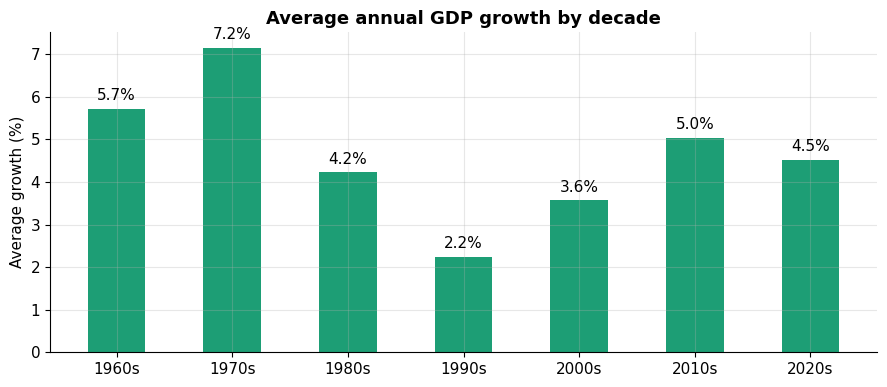

In [45]:
# ── Decade-average GDP growth ──────────────────────────────────────────────
gdp_growth_df = gdp_growth.reset_index()
gdp_growth_df.columns = ['Year', 'Growth']
gdp_growth_df['Decade'] = (gdp_growth_df['Year'] // 10) * 10
decade_avg = gdp_growth_df.groupby('Decade')['Growth'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(decade_avg.index.astype(str) + 's', decade_avg.values,
              color=PALETTE[0], width=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_title('Average annual GDP growth by decade')
ax.set_ylabel('Average growth (%)')
plt.tight_layout()
plt.show()

## 4. Health & demographics

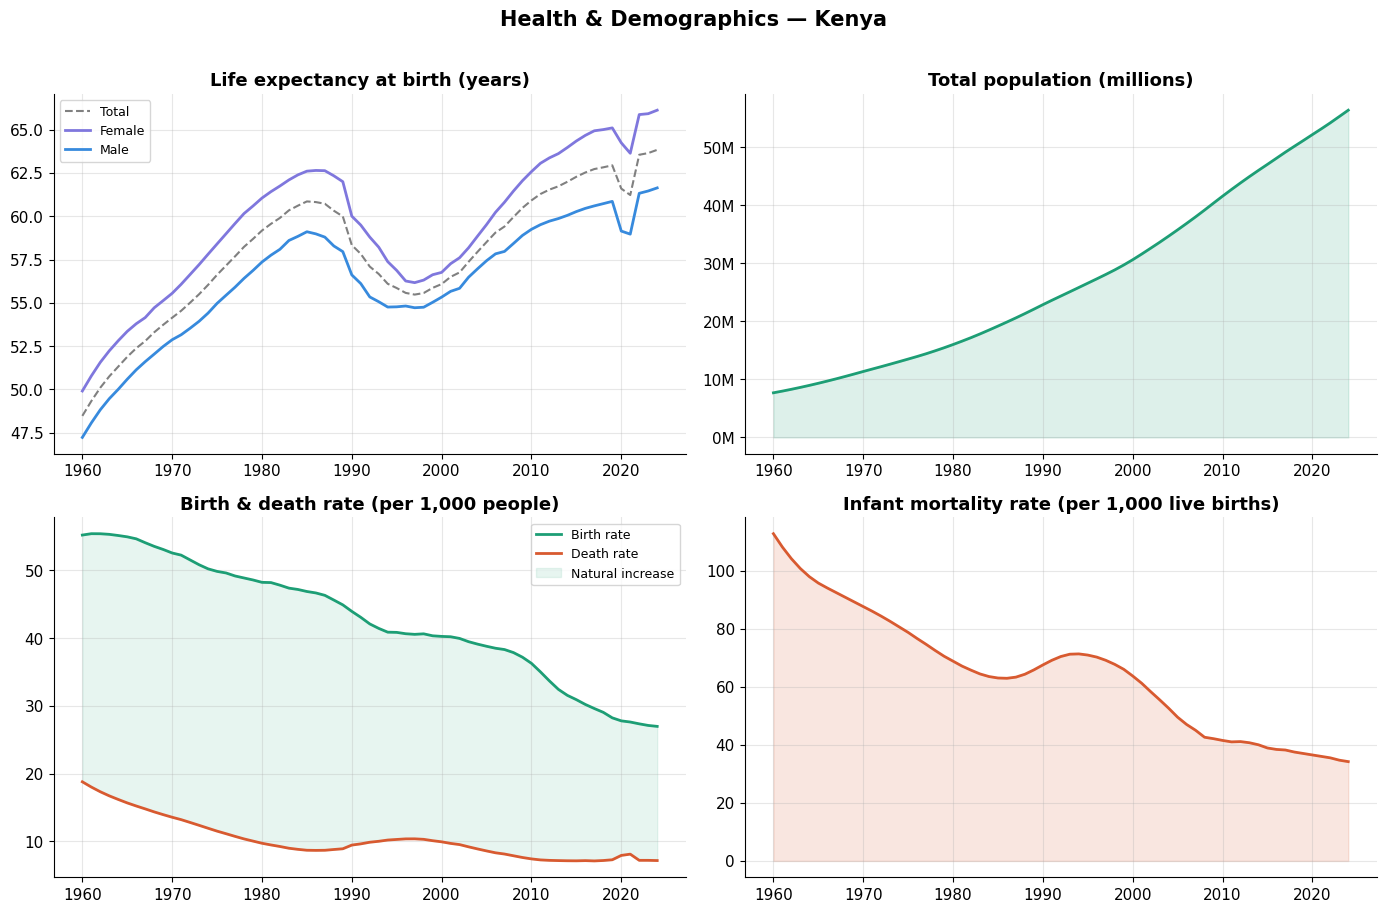

In [46]:
life_exp    = get_series('Life expectancy at birth, total (years)')
life_exp_f  = get_series('Life expectancy at birth, female (years)')
life_exp_m  = get_series('Life expectancy at birth, male (years)')
population  = get_series('Population, total') / 1e6
birth_rate  = get_series('Birth rate, crude (per 1,000 people)')
death_rate  = get_series('Death rate, crude (per 1,000 people)')
infant_mort = get_series('Mortality rate, infant (per 1,000 live births)')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Health & Demographics — Kenya', fontsize=15, fontweight='bold', y=1.01)

# Life expectancy by gender
ax = axes[0, 0]
ax.plot(life_exp.index,   life_exp.values,   color='gray',     linewidth=1.5, linestyle='--', label='Total')
ax.plot(life_exp_f.index, life_exp_f.values, color=PALETTE[3], linewidth=2,   label='Female')
ax.plot(life_exp_m.index, life_exp_m.values, color=PALETTE[1], linewidth=2,   label='Male')
ax.set_title('Life expectancy at birth (years)')
ax.legend(fontsize=9)

# Population
ax = axes[0, 1]
ax.fill_between(population.index, population.values, alpha=0.15, color=PALETTE[0])
ax.plot(population.index, population.values, color=PALETTE[0], linewidth=2)
ax.set_title('Total population (millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

# Birth vs death rate
ax = axes[1, 0]
ax.plot(birth_rate.index, birth_rate.values, color=PALETTE[0], linewidth=2, label='Birth rate')
ax.plot(death_rate.index, death_rate.values, color=PALETTE[2], linewidth=2, label='Death rate')
ax.fill_between(
    birth_rate.index,
    birth_rate.values,
    death_rate.reindex(birth_rate.index).values,
    alpha=0.1, color=PALETTE[0], label='Natural increase'
)
ax.set_title('Birth & death rate (per 1,000 people)')
ax.legend(fontsize=9)

# Infant mortality
ax = axes[1, 1]
ax.fill_between(infant_mort.index, infant_mort.values, alpha=0.15, color=PALETTE[2])
ax.plot(infant_mort.index, infant_mort.values, color=PALETTE[2], linewidth=2)
ax.set_title('Infant mortality rate (per 1,000 live births)')

plt.tight_layout()
plt.show()

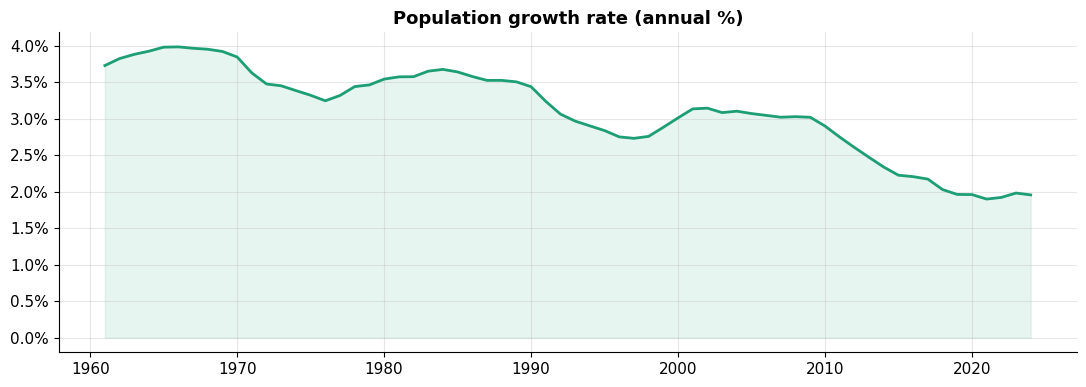

Peak population growth: 3.99% in 1966
Most recent (2023):     1.98%


In [47]:
# ── Population growth rate ─────────────────────────────────────────────────
pop_growth = get_series('Population growth (annual %)')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(pop_growth.index, pop_growth.values, color=PALETTE[0], linewidth=2)
ax.fill_between(pop_growth.index, pop_growth.values, alpha=0.1, color=PALETTE[0])
ax.set_title('Population growth rate (annual %)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.show()

print(f'Peak population growth: {pop_growth.max():.2f}% in {pop_growth.idxmax()}')
print(f'Most recent (2023):     {pop_growth.get(2023, float("nan")):.2f}%')

## 5. Education

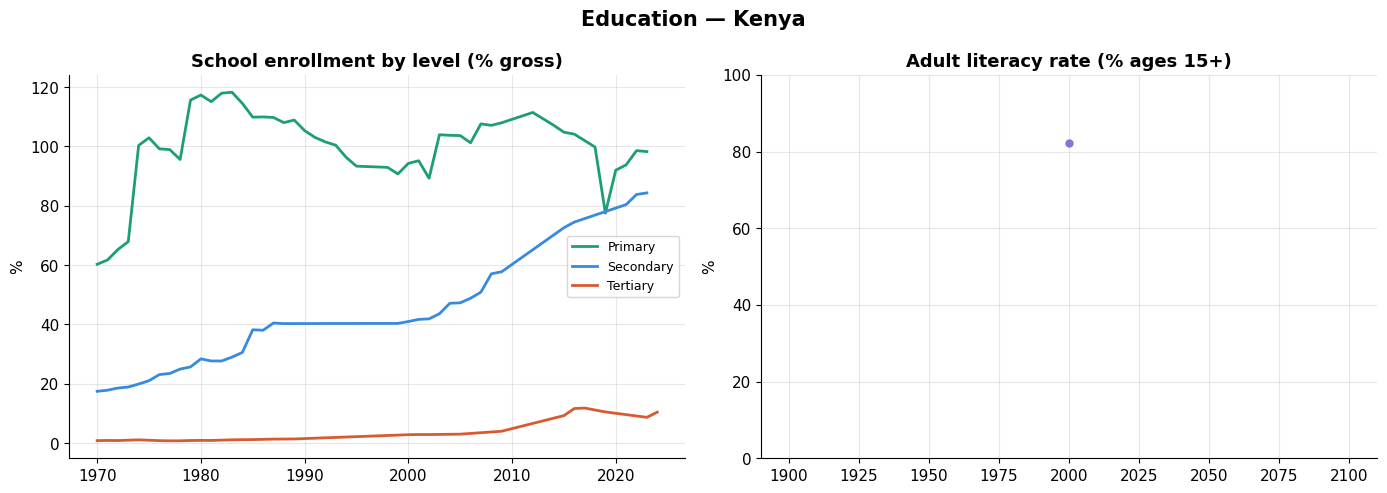

In [48]:
primary_enroll   = get_series('School enrollment, primary (% gross)')
secondary_enroll = get_series('School enrollment, secondary (% gross)')
tertiary_enroll  = get_series('School enrollment, tertiary (% gross)')
literacy_adult   = get_series('Literacy rate, adult total (% of people ages 15 and above)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Education — Kenya', fontsize=15, fontweight='bold')

# Enrollment rates by level
ax = axes[0]
ax.plot(primary_enroll.index,   primary_enroll.values,   color=PALETTE[0], linewidth=2, label='Primary')
ax.plot(secondary_enroll.index, secondary_enroll.values, color=PALETTE[1], linewidth=2, label='Secondary')
ax.plot(tertiary_enroll.index,  tertiary_enroll.values,  color=PALETTE[2], linewidth=2, label='Tertiary')
ax.set_title('School enrollment by level (% gross)')
ax.set_ylabel('%')
ax.legend(fontsize=9)

# Literacy
ax = axes[1]
ax.plot(literacy_adult.index, literacy_adult.values, color=PALETTE[3], linewidth=2, marker='o', markersize=5)
ax.set_title('Adult literacy rate (% ages 15+)')
ax.set_ylabel('%')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

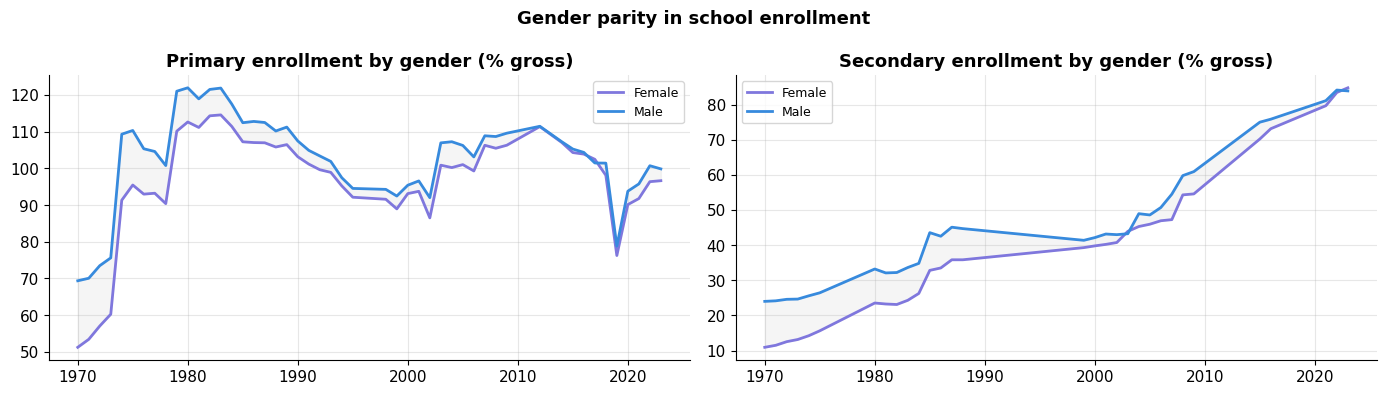

In [49]:
# ── Gender parity in education ─────────────────────────────────────────────
gpi_primary   = get_series('School enrollment, primary, female (% gross)')
gpi_secondary = get_series('School enrollment, secondary, female (% gross)')
male_primary   = get_series('School enrollment, primary, male (% gross)')
male_secondary = get_series('School enrollment, secondary, male (% gross)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Gender parity in school enrollment', fontsize=13, fontweight='bold')

for ax, fem, mal, level in zip(
    axes,
    [gpi_primary, gpi_secondary],
    [male_primary, male_secondary],
    ['Primary', 'Secondary']
):
    common = fem.index.intersection(mal.index)
    ax.plot(common, fem.reindex(common).values, color=PALETTE[3], linewidth=2, label='Female')
    ax.plot(common, mal.reindex(common).values, color=PALETTE[1], linewidth=2, label='Male')
    ax.fill_between(common,
                    fem.reindex(common).values,
                    mal.reindex(common).values,
                    alpha=0.08, color='gray')
    ax.set_title(f'{level} enrollment by gender (% gross)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Trade & exports

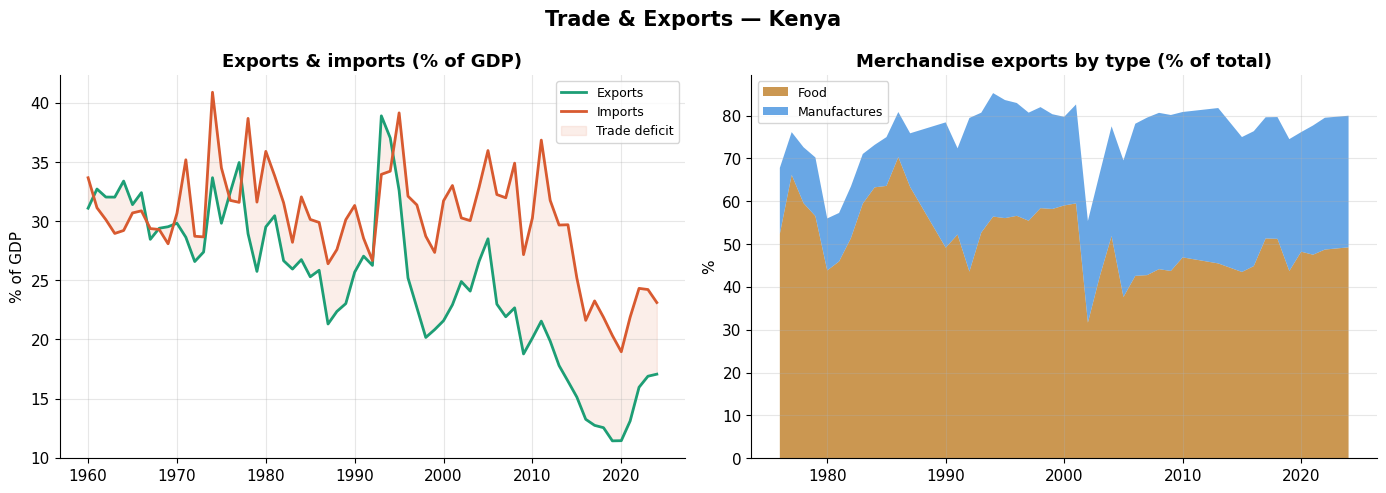

In [50]:
exports_gdp   = get_series('Exports of goods and services (% of GDP)')
imports_gdp   = get_series('Imports of goods and services (% of GDP)')
trade_gdp     = get_series('Trade (% of GDP)')
food_exp      = get_series('Food exports (% of merchandise exports)')
manuf_exp     = get_series('Manufactures exports (% of merchandise exports)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trade & Exports — Kenya', fontsize=15, fontweight='bold')

# Exports vs imports as % of GDP
ax = axes[0]
ax.plot(exports_gdp.index, exports_gdp.values, color=PALETTE[0], linewidth=2, label='Exports')
ax.plot(imports_gdp.index, imports_gdp.values, color=PALETTE[2], linewidth=2, label='Imports')
ax.fill_between(
    imports_gdp.index,
    exports_gdp.reindex(imports_gdp.index, fill_value=np.nan).values,
    imports_gdp.values,
    alpha=0.1, color=PALETTE[2], label='Trade deficit'
)
ax.set_title('Exports & imports (% of GDP)')
ax.set_ylabel('% of GDP')
ax.legend(fontsize=9)

# Merchandise export composition
ax = axes[1]
common = food_exp.index.intersection(manuf_exp.index)
ax.stackplot(common,
             food_exp.reindex(common).values,
             manuf_exp.reindex(common).values,
             labels=['Food', 'Manufactures'],
             colors=[PALETTE[4], PALETTE[1]], alpha=0.75)
ax.set_title('Merchandise exports by type (% of total)')
ax.set_ylabel('%')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

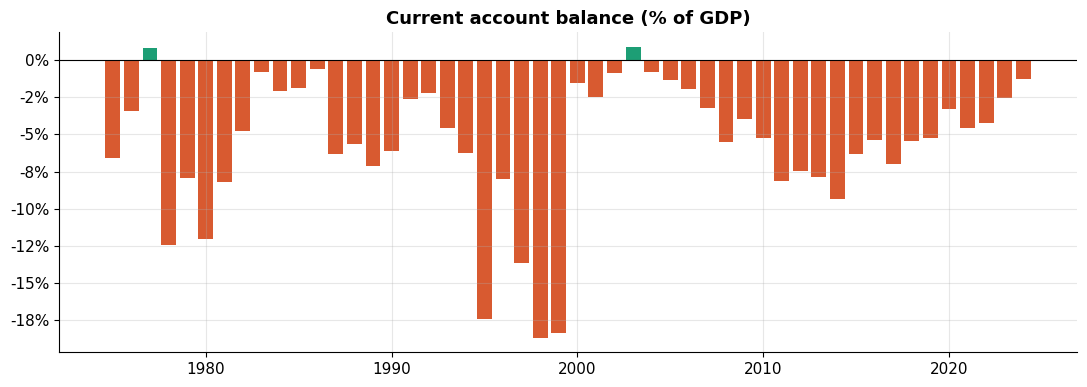

In [51]:
# ── Current account balance ────────────────────────────────────────────────
try:
    cur_acct = get_series('Current account balance (% of GDP)')
    fig, ax = plt.subplots(figsize=(11, 4))
    colors_ca = [PALETTE[0] if v >= 0 else PALETTE[2] for v in cur_acct.values]
    ax.bar(cur_acct.index, cur_acct.values, color=colors_ca, width=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Current account balance (% of GDP)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    plt.tight_layout()
    plt.show()
except ValueError as e:
    print(f'Indicator not available: {e}')

## 7. Digital & infrastructure

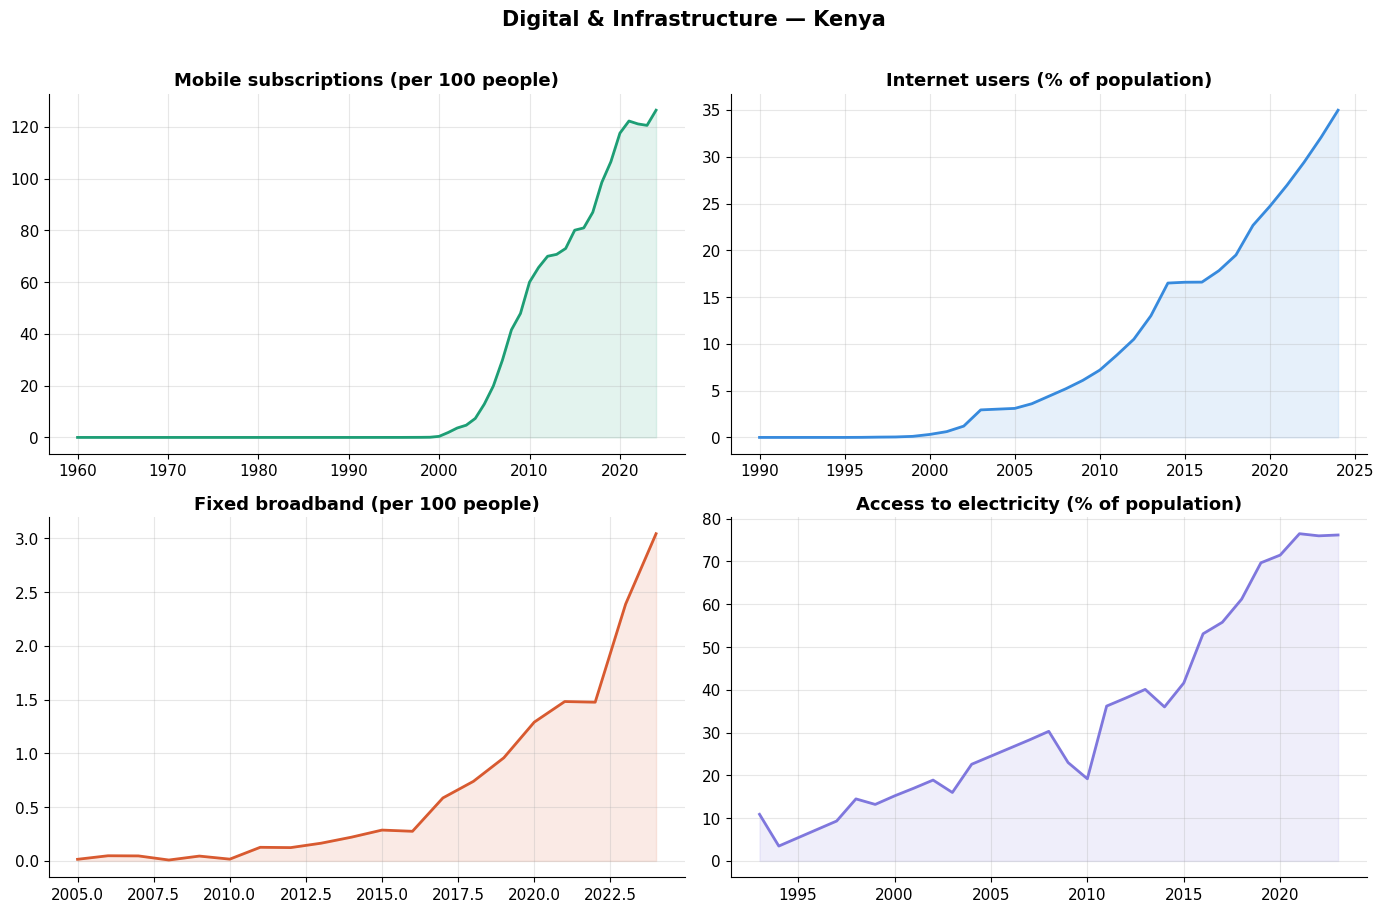

In [52]:
mobile       = get_series('Mobile cellular subscriptions (per 100 people)')
internet     = get_series('Individuals using the Internet (% of population)')
fixed_bb     = get_series('Fixed broadband subscriptions (per 100 people)')
electricity  = get_series('Access to electricity (% of population)')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Digital & Infrastructure — Kenya', fontsize=15, fontweight='bold', y=1.01)

for ax, series, title, color in zip(
    axes.flat,
    [mobile, internet, fixed_bb, electricity],
    ['Mobile subscriptions (per 100 people)',
     'Internet users (% of population)',
     'Fixed broadband (per 100 people)',
     'Access to electricity (% of population)'],
    PALETTE
):
    ax.fill_between(series.index, series.values, alpha=0.12, color=color)
    ax.plot(series.index, series.values, color=color, linewidth=2)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [53]:
# ── Digital adoption scorecard ─────────────────────────────────────────────
benchmarks = {
    'Mobile subscriptions': (mobile, 'per 100 people'),
    'Internet users':       (internet, '% of population'),
    'Fixed broadband':      (fixed_bb, 'per 100 people'),
    'Electricity access':   (electricity, '% of population'),
}

rows = []
for label, (series, unit) in benchmarks.items():
    rows.append({
        'Indicator': label,
        'Unit': unit,
        '2010': round(series.get(2010, np.nan), 1),
        '2015': round(series.get(2015, np.nan), 1),
        '2020': round(series.get(2020, np.nan), 1),
        'Latest': round(series.iloc[-1], 1),
        'Latest year': int(series.index[-1])
    })

display(pd.DataFrame(rows).set_index('Indicator'))

,Unit,2010,2015,2020,Latest,Latest year
Indicator,,,,,,
Mobile subscriptions,per 100 people,60.0,80.1,117.6,126.5,2024
Internet users,% of population,7.2,16.6,24.7,35.0,2024
Fixed broadband,per 100 people,0.0,0.3,1.3,3.0,2024
Electricity access,% of population,19.2,41.6,71.5,76.2,2023


## 8. Cross-theme correlation analysis

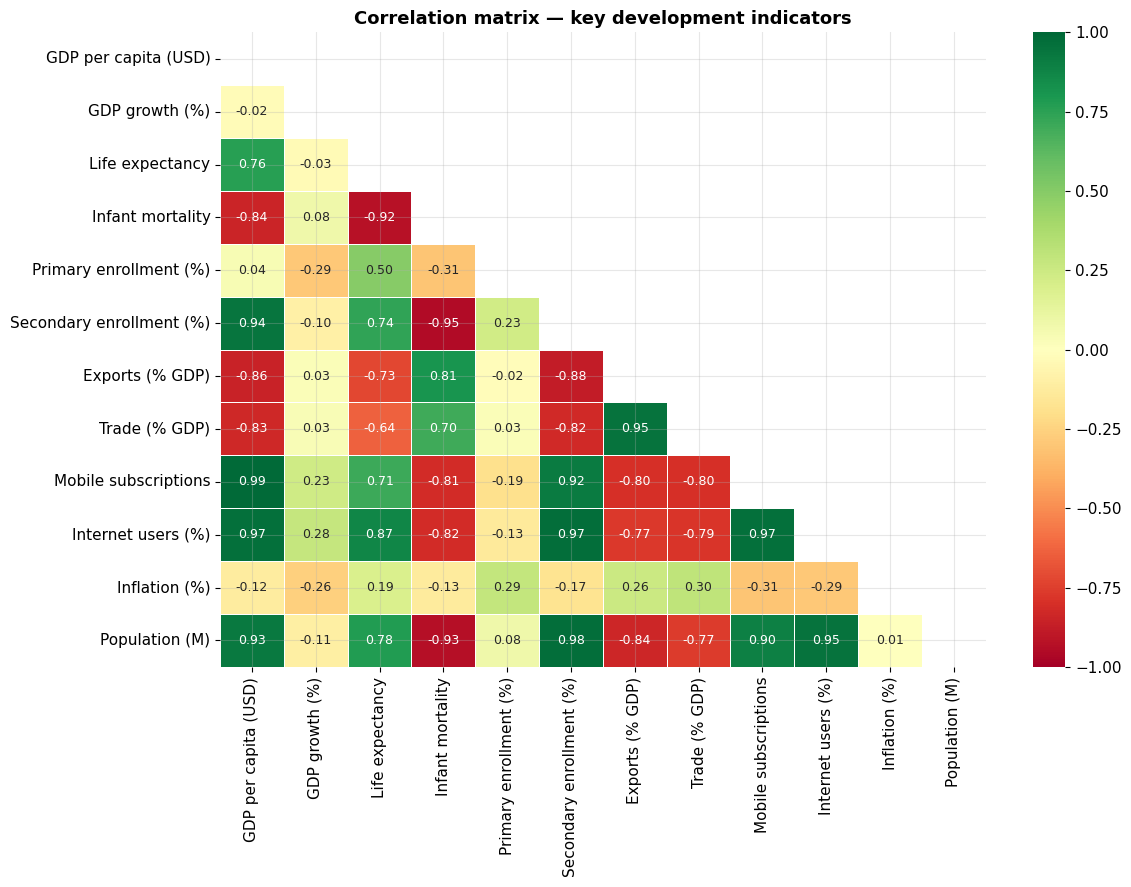

In [54]:
# ── Build a tidy cross-theme dataframe ────────────────────────────────────
indicators = {
    'GDP per capita (USD)':          'GDP per capita (current US$)',
    'GDP growth (%)':                'GDP growth (annual %)',
    'Life expectancy':               'Life expectancy at birth, total (years)',
    'Infant mortality':              'Mortality rate, infant (per 1,000 live births)',
    'Primary enrollment (%)':        'School enrollment, primary (% gross)',
    'Secondary enrollment (%)':      'School enrollment, secondary (% gross)',
    'Exports (% GDP)':               'Exports of goods and services (% of GDP)',
    'Trade (% GDP)':                 'Trade (% of GDP)',
    'Mobile subscriptions':          'Mobile cellular subscriptions (per 100 people)',
    'Internet users (%)':            'Individuals using the Internet (% of population)',
    'Inflation (%)':                 'Inflation, consumer prices (annual %)',
    'Population (M)':                'Population, total',
}

df_corr = pd.DataFrame()
for col, ind in indicators.items():
    try:
        df_corr[col] = get_series(ind)
    except ValueError:
        print(f'  Skipped (not found): {ind}')

df_corr['Population (M)'] = df_corr.get('Population (M)', pd.Series(dtype=float)) / 1e6

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Correlation matrix — key development indicators', fontsize=13)
plt.tight_layout()
plt.show()

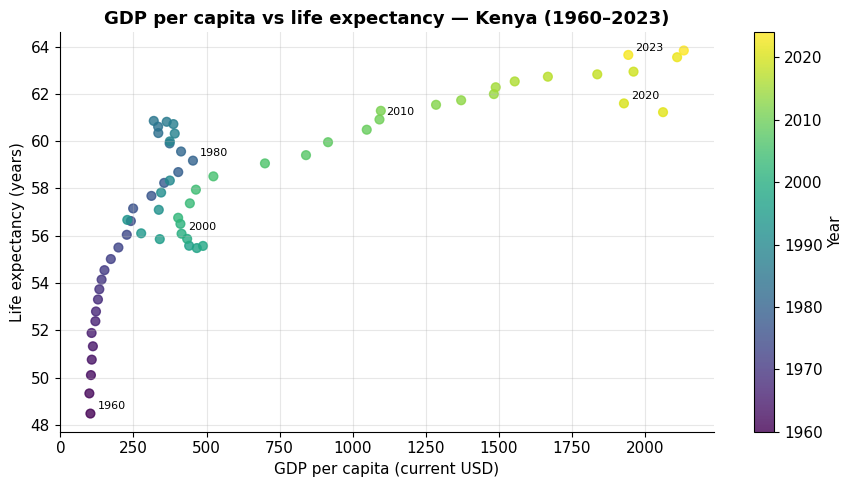

In [55]:
# ── Scatter: GDP per capita vs life expectancy ─────────────────────────────
gdp_pc_s   = get_series('GDP per capita (current US$)')
life_exp_s = get_series('Life expectancy at birth, total (years)')
common     = gdp_pc_s.index.intersection(life_exp_s.index)

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    gdp_pc_s[common], life_exp_s[common],
    c=common, cmap='viridis', s=40, alpha=0.8
)
plt.colorbar(sc, ax=ax, label='Year')
# Annotate a few key years
for yr in [1960, 1980, 2000, 2010, 2020, 2023]:
    if yr in common:
        ax.annotate(str(yr), (gdp_pc_s[yr], life_exp_s[yr]),
                    fontsize=8, xytext=(5, 3), textcoords='offset points')
ax.set_xlabel('GDP per capita (current USD)')
ax.set_ylabel('Life expectancy (years)')
ax.set_title('GDP per capita vs life expectancy — Kenya (1960–2023)')
plt.tight_layout()
plt.show()

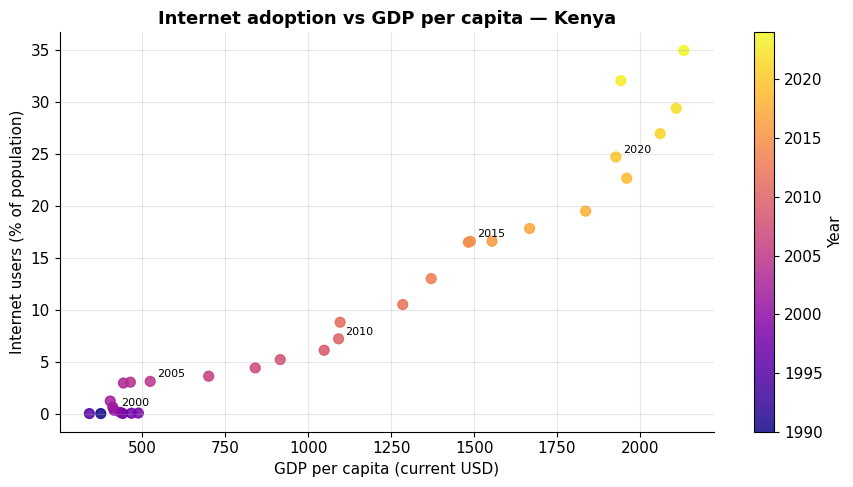

In [56]:
# ── Internet adoption vs GDP per capita ────────────────────────────────────
internet_s = get_series('Individuals using the Internet (% of population)')
common2    = gdp_pc_s.index.intersection(internet_s.index)

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    gdp_pc_s[common2], internet_s[common2],
    c=common2, cmap='plasma', s=50, alpha=0.85
)
plt.colorbar(sc, ax=ax, label='Year')
for yr in [2000, 2005, 2010, 2015, 2020]:
    if yr in common2:
        ax.annotate(str(yr), (gdp_pc_s[yr], internet_s[yr]),
                    fontsize=8, xytext=(5, 3), textcoords='offset points')
ax.set_xlabel('GDP per capita (current USD)')
ax.set_ylabel('Internet users (% of population)')
ax.set_title('Internet adoption vs GDP per capita — Kenya')
plt.tight_layout()
plt.show()

## 9. Key findings & conclusions

### Economic trajectory
- Kenya's GDP grew from roughly **$0.8B in 1960 to $107B in 2023** — a 130× increase in nominal terms.
- Growth has been broadly positive, with the 2000s being the strongest decade. The only major contraction in recent history was **2020 (COVID-19, -0.3%)**.
- Inflation has been persistently elevated (double digits in the 1990s), but moderated to ~4.5% by 2024.

### Health progress
- Life expectancy rose from **48.5 to 63.6 years** over six decades — a major public health achievement.
- There was a notable **dip in the 1990s–early 2000s**, consistent with the HIV/AIDS epidemic impact.
- Infant mortality fell sharply from ~120 per 1,000 in 1960 to under 30 today.
- The birth–death rate gap is narrowing, signalling a **demographic transition** underway.

### Education
- Primary enrollment is near universal (~98%), but secondary enrollment still lags.
- Gender parity at the primary level has improved significantly since the 1980s.
- Tertiary enrollment remains low but is growing, reflecting a maturing education system.

### Trade
- Kenya consistently runs a **trade deficit** — imports exceed exports as a share of GDP.
- Food exports dominate merchandise, though manufactured exports are slowly rising.

### Digital leap
- Kenya's mobile adoption is a standout story — **126 subscriptions per 100 people** by 2024 (multisim).
- Internet users grew from nearly 0% to **38% by 2024**, underpinning the fintech and digital economy boom.
- Fixed broadband remains low, suggesting mobile-first internet access dominates.

### Correlations
- Strong positive correlation between **GDP per capita and life expectancy**, consistent with the Preston curve.
- Internet adoption accelerated sharply after 2007, tracking both GDP growth and mobile infrastructure.
- Infant mortality is strongly negatively correlated with GDP per capita.

---
*Dataset: World Bank World Development Indicators — Kenya (API_KEN_DS2_en_csv_v2_5938.csv)*